# Optimize a Four-Bar Linkage with PSO

This notebook demonstrates the full optimization loop: define a four-bar linkage,
write a fitness function, and use Particle Swarm Optimization to find the best
link lengths for a given objective.

**Objective:** Maximize the horizontal range of the coupler point trajectory
(useful for conveyor, pick-and-place, or walking mechanisms).

**What you'll learn:**
- Building a parameterized linkage
- Writing a fitness function with `@kinematic_maximization`
- Running PSO with `particle_swarm_optimization()`
- Comparing initial vs optimized coupler curves

In [8]:
import warnings

import matplotlib.pyplot as plt

from pylinkage import (
    generate_bounds,
    kinematic_maximization,
    particle_swarm_optimization,
)
from pylinkage.synthesis import fourbar_from_lengths

warnings.filterwarnings('ignore', category=DeprecationWarning)

## 1. Build the Initial Four-Bar

A simple crank-rocker with ground length 4. We'll optimize the crank (a),
coupler (b), and rocker (c) lengths.

In [9]:
GROUND_LENGTH = 4.0

def build_fourbar(a, b, c):
    """Build a four-bar linkage with given link lengths."""
    return fourbar_from_lengths(
        crank_length=a,
        coupler_length=b,
        rocker_length=c,
        ground_length=GROUND_LENGTH,
        iterations=100,
    )

# Initial link lengths
initial = (1.0, 3.0, 3.0)
linkage = build_fourbar(*initial)
print(f'Joints: {[j.name for j in linkage.joints]}')
print(f'Constraints: {linkage.get_num_constraints(flat=True)}')

Joints: ['A', 'D', 'B', 'C']
Constraints: [1.0, 3.0, 3.0]


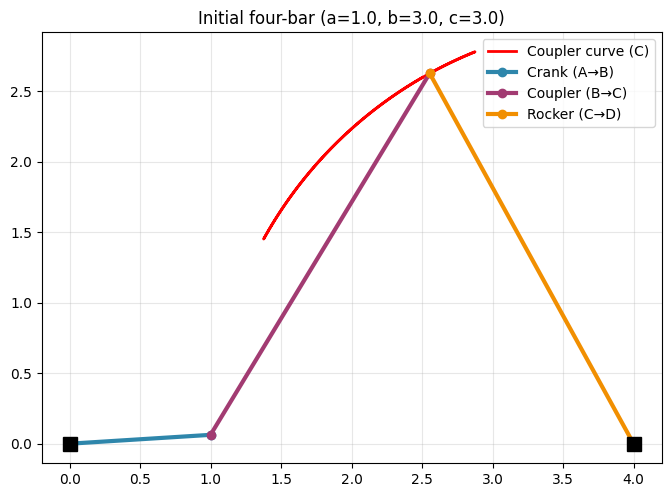

Horizontal range: 1.500


In [10]:
# Simulate and plot the initial coupler curve with mechanism
loci = list(linkage.step(iterations=100))
c_path = [(pos[-1][0], pos[-1][1]) for pos in loci if pos[-1][0] is not None]
cx, cy = zip(*c_path, strict=False)

fig, ax = plt.subplots(figsize=(8, 6))

# Coupler curve
ax.plot(cx, cy, 'r-', linewidth=2, label='Coupler curve (C)')

# Draw the mechanism at its initial position (frame 0)
pos = loci[0]
link_labels = ['Crank (A→B)', 'Coupler (B→C)', 'Rocker (C→D)']
link_colors = ['#2E86AB', '#A23B72', '#F18F01']
for (i, j), color, label in zip([(0, 2), (2, 3), (3, 1)], link_colors, link_labels, strict=False):
    ax.plot([pos[i][0], pos[j][0]], [pos[i][1], pos[j][1]],
            '-o', color=color, linewidth=3, markersize=6, label=label)

ax.plot(0, 0, 'ks', markersize=10, zorder=5)
ax.plot(GROUND_LENGTH, 0, 'ks', markersize=10, zorder=5)
ax.set_title(f'Initial four-bar (a={initial[0]}, b={initial[1]}, c={initial[2]})')
ax.set_aspect('equal')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

x_range = max(cx) - min(cx)
print(f'Horizontal range: {x_range:.3f}')

## 2. Define the Fitness Function

The `@kinematic_maximization` decorator handles:
- Setting constraints on the linkage
- Running the simulation
- Catching `UnbuildableError` (returns `-inf`)

The decorated function receives the simulation loci and returns the score to maximize.

In [11]:
@kinematic_maximization
def horizontal_range(loci, **kwargs):
    """Maximize horizontal range of the coupler point trajectory."""
    # Last joint is C (the coupler-rocker joint)
    c_path = [(pos[-1][0], pos[-1][1]) for pos in loci
              if pos[-1][0] is not None]
    if len(c_path) < 10:
        return 0.0
    xs = [p[0] for p in c_path]
    return max(xs) - min(xs)

# Quick test
score = horizontal_range(linkage, list(initial), None)
print(f"Initial fitness: {score:.3f}")

Initial fitness: 1.500


## 3. Run Particle Swarm Optimization

PSO explores the parameter space with a swarm of candidate solutions.
`generate_bounds()` creates search bounds around the initial values.

In [12]:
center = list(initial)
lower, upper = generate_bounds(center, min_ratio=3, max_factor=3)
print('Search bounds:')
print(f'  Lower: {lower}')
print(f'  Upper: {upper}')

results = particle_swarm_optimization(
    horizontal_range,
    linkage,
    center=center,
    dimensions=len(center),
    n_particles=40,
    iters=80,
    bounds=(tuple(lower), tuple(upper)),
    order_relation=max,
    verbose=True,
)

best = results[0]
print(f'\nBest score: {best.score:.4f}')
print(
    f'Best dimensions: a={best.dimensions[0]:.3f}, '
    f'b={best.dimensions[1]:.3f}, c={best.dimensions[2]:.3f}'
)

Search bounds:
  Lower: [0.33333333 1.         1.        ]
  Upper: [3. 9. 9.]
PSO iter 80/80  best cost: -4.731007

Best score: 4.7310
Best dimensions: a=1.767, b=5.356, c=3.624


## 4. Compare Before and After

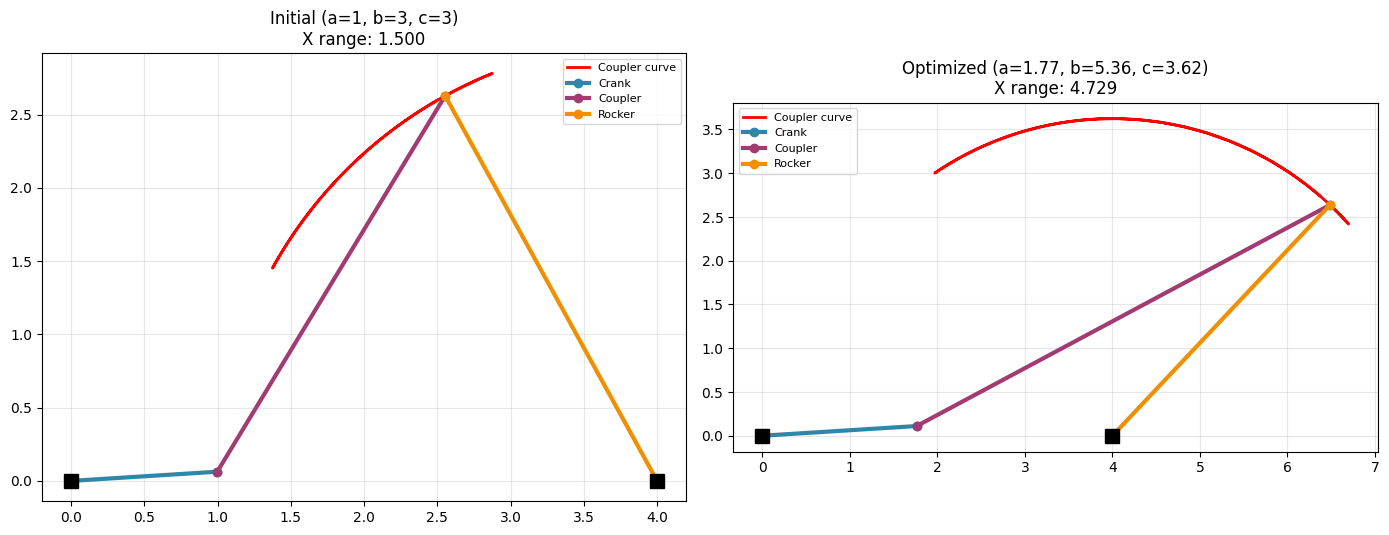

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

link_pairs = [(0, 2), (2, 3), (3, 1)]  # A-B, B-C, C-D
link_labels = ['Crank', 'Coupler', 'Rocker']
link_colors = ['#2E86AB', '#A23B72', '#F18F01']

def plot_coupler(ax, a, b, c, title):
    lk = build_fourbar(a, b, c)
    loci = list(lk.step(iterations=100))
    path = [(pos[-1][0], pos[-1][1]) for pos in loci if pos[-1][0] is not None]

    if path:
        px, py = zip(*path, strict=False)
        ax.plot(px, py, 'r-', linewidth=2, label='Coupler curve')
        x_range = max(px) - min(px)
        ax.set_title(f'{title}\nX range: {x_range:.3f}')

    # Draw mechanism at initial position
    pos = loci[0]
    for (i, j), color, label in zip(link_pairs, link_colors, link_labels, strict=False):
        ax.plot([pos[i][0], pos[j][0]], [pos[i][1], pos[j][1]],
                '-o', color=color, linewidth=3, markersize=6, label=label)

    ax.plot(0, 0, 'ks', markersize=10, zorder=5)
    ax.plot(GROUND_LENGTH, 0, 'ks', markersize=10, zorder=5)
    ax.set_aspect('equal')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plot_coupler(ax1, *initial, 'Initial (a=1, b=3, c=3)')
d = best.dimensions
plot_coupler(ax2, d[0], d[1], d[2],
             f'Optimized (a={d[0]:.2f}, b={d[1]:.2f}, c={d[2]:.2f})')

plt.tight_layout()
plt.show()

## 5. Overlay on Same Axes

In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))

link_pairs = [(0, 2), (2, 3), (3, 1)]  # A-B, B-C, C-D

# Initial
lk1 = build_fourbar(*initial)
loci1 = list(lk1.step(iterations=100))
p1 = [(pos[-1][0], pos[-1][1]) for pos in loci1 if pos[-1][0] is not None]
if p1:
    ax.plot(*zip(*p1, strict=False), 'b--', linewidth=1.5, alpha=0.6, label='Initial curve')
# Draw initial mechanism
pos1 = loci1[0]
for (i, j), color in zip(link_pairs, ['#2E86AB', '#A23B72', '#F18F01'], strict=False):
    ax.plot([pos1[i][0], pos1[j][0]], [pos1[i][1], pos1[j][1]],
            '--o', color=color, linewidth=2, markersize=5, alpha=0.5)

# Optimized
lk2 = build_fourbar(d[0], d[1], d[2])
loci2 = list(lk2.step(iterations=100))
p2 = [(pos[-1][0], pos[-1][1]) for pos in loci2 if pos[-1][0] is not None]
if p2:
    ax.plot(*zip(*p2, strict=False), 'r-', linewidth=2, label='Optimized curve')
# Draw optimized mechanism
pos2 = loci2[0]
labels = ['Crank', 'Coupler', 'Rocker']
colors = ['#2E86AB', '#A23B72', '#F18F01']
for (i, j), color, label in zip(link_pairs, colors, labels, strict=False):
    ax.plot([pos2[i][0], pos2[j][0]], [pos2[i][1], pos2[j][1]],
            '-o', color=color, linewidth=3, markersize=6, label=f'{label} (opt)')

ax.plot(0, 0, 'ks', markersize=10, zorder=5)
ax.plot(GROUND_LENGTH, 0, 'ks', markersize=10, zorder=5)
ax.set_title('Coupler curves: initial vs optimized')
ax.set_aspect('equal')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Interactive Exploration

Use the slider to drive the optimized linkage and explore its motion interactively.

In [15]:
from pylinkage.visualizer import interactive_linkage_plotly

# Build the optimized linkage for interactive exploration
opt_linkage = build_fourbar(d[0], d[1], d[2])
interactive_linkage_plotly(opt_linkage, title="Optimized four-bar — drag the slider")


…

## Summary

1. Built a parameterized four-bar linkage with `fourbar_from_lengths()`
2. Defined a fitness function with `@kinematic_maximization`
3. Ran PSO with `particle_swarm_optimization()` to maximize coupler X range
4. Compared coupler curves before and after optimization

**Other objectives you can optimize for:**
- Path straightness (minimize y deviation)
- Proximity to target points
- Transmission angle quality
- Minimum link length ratios (for manufacturability)

**Other optimizers available:**
- `trials_and_errors_optimization()` -- grid search
- `differential_evolution_optimization()` -- scipy DE
- `multi_objective_optimization()` -- Pareto front (requires `pymoo`)